# Supermarket Feature Analysis    

**Dominic Kirby**

## Introduction 

In this notebook we will assess the impact of various features on the profit and sales of products in various stores across the USA, we will investigate the profit per city, category, sub-category, and customer segment. Furthermore, we will go into detail on the affect of discount of sales and profit as well as reasoning the results we see in the sub-category investigation.


### Initial step

We will use Pandas and NumPy packages for understanding the information the file holds, with Seaborn and MatPlotLib for visualisation of the results we find. 

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

with open ("superstore.csv") as csv:
    df = pd.read_csv(csv)

# Information about the dataset
print("The data is taken from", df['Order Date'].min(), "to", df['Order Date'].max(), "across", len(df), 'orders.')

The data is taken from 1/1/2017 to 9/9/2017 across 9994 orders.


## Data cleaning

In this section we will convert the information into the datatypes we want, remove any duplicates, and create several new values to assess better the variation in results over time, being filtering out month per row and year per row as well as a combined month and year value to view the data per month and per year instead of per date. 

In [2]:
# Data Cleaning
df = df.drop_duplicates()
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])
df['Month and Year'] = df['Order Date'].dt.to_period('M')
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month

df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 9994 entries, 0 to 9993
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          9994 non-null   int64         
 1   Order ID        9994 non-null   object        
 2   Order Date      9994 non-null   datetime64[ns]
 3   Ship Date       9994 non-null   datetime64[ns]
 4   Ship Mode       9994 non-null   object        
 5   Customer ID     9994 non-null   object        
 6   Customer Name   9994 non-null   object        
 7   Segment         9994 non-null   object        
 8   Country         9994 non-null   object        
 9   City            9994 non-null   object        
 10  State           9994 non-null   object        
 11  Postal Code     9994 non-null   int64         
 12  Region          9994 non-null   object        
 13  Product ID      9994 non-null   object        
 14  Category        9994 non-null   object        
 15  Sub-

In [3]:
# Example rows 
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Month and Year,Year,Month
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016-11,2016,11
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016-11,2016,11
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016-06,2016,6
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015-10,2015,10
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015-10,2015,10


## Data Investigation

Now the data is cleaned we go into the investigative phase of this document, this first section is purely numerical and informative to give context to further investigation later. The features we will look into are in order as follows: city, category, sub-category, customer segment, and shipping mode.

### City grouping and ordering

First we will look into the sum of profit per location and slice the top 5 and bottom 5 for context. 

In [4]:
# Grouping the data by city and summing total profit per city
city_grouped = df.groupby('City')['Profit'].sum()
city_grouped_desc = city_grouped.sort_values(ascending = False)
city_grouped_asc = city_grouped.sort_values(ascending = True)


In [5]:
city_grouped_asc.head()

City
Philadelphia   -13837.7674
Houston        -10153.5485
San Antonio     -7299.0502
Lancaster       -7239.0684
Chicago         -6654.5688
Name: Profit, dtype: float64

In [6]:
city_grouped_desc.head()

City
New York City    62036.9837
Los Angeles      30440.7579
Seattle          29156.0967
San Francisco    17507.3854
Detroit          13181.7908
Name: Profit, dtype: float64

As we can see the bottom is Philadelphia with nearly negative $\$14,000$ in loss over the duration of this data and the highest grossing city is New York City with over $\$62,000$ profit over the course of this data collection.

### Category grouping and ordering

The next difference we will look at is the profit per category of sale, out of Technology, Office Supplies, and Furniture. Same as before we wil group by Category and look at the sum of profit for each option, then order and view the results. 

In [7]:
# Grouping the data by category and summing total profit per category
category_grouped = df.groupby('Category')['Profit'].sum()
category_grouped.sort_values(ascending = False, inplace = True)
category_grouped.head()

Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64

As we can see the most obvious result is the severe discrepancy that furniture has a fraction of the profit of the other two categories, to visualise why this might be we can look at the split of furniture into smaller categories and view the profit for each.

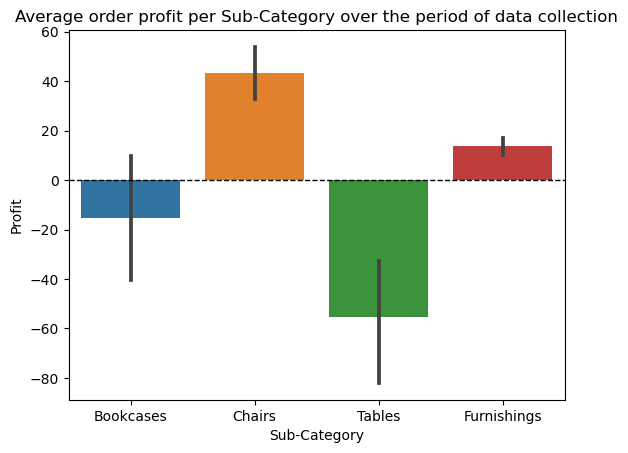

In [8]:
# Filtering furniture only
furniture_category_only = df[df['Category']  == 'Furniture']

# Showing the average profit per subcategory in furniture
sns.barplot(data = furniture_category_only, x = 'Sub-Category', y = 'Profit')
plt.title('Average order profit per Sub-Category over the period of data collection')
plt.axhline(0, color='black', linewidth=1, linestyle='--')
plt.show()

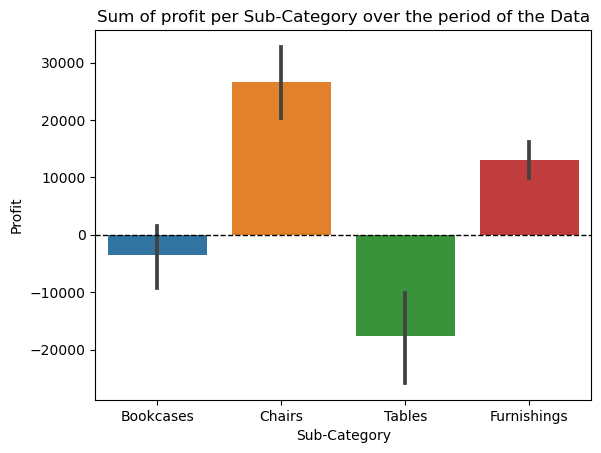

In [9]:
# Showing the total profit per subcategory in furniture
sns.barplot(data = furniture_category_only, x = 'Sub-Category', y = 'Profit', estimator = 'sum')
plt.title('Sum of profit per Sub-Category over the period of the Data')
plt.axhline(0, color='black', linewidth=1, linestyle='--')
plt.show()

We now see that the reasoning behind why furniture was severely underperforming, the tables are being sold at a severe loss on average, and in total. In comparison, chairs are being sold at a good profit which counteracts most of the profit loss but the main focal point should be why tables is underselling by so much.

### Sub-Category grouping and ordering

Following on from the previous point we can look in general at all sub-category performance over the whole dataset. We will sum the total profit for each then look at the top 5 and bottom 5 sub-categories for profit.

In [10]:
# Grouping the data by subcategory and summing total profit in each
subcategory_grouped = df.groupby('Sub-Category')['Profit'].sum()
subcategory_grouped_desc = subcategory_grouped.sort_values(ascending = False)
subcategory_grouped_asc = subcategory_grouped.sort_values(ascending = True)

In [11]:
subcategory_grouped_desc.head()

Sub-Category
Copiers        55617.8249
Phones         44515.7306
Accessories    41936.6357
Paper          34053.5693
Binders        30221.7633
Name: Profit, dtype: float64

In [12]:
subcategory_grouped_asc.head()

Sub-Category
Tables      -17725.4811
Bookcases    -3472.5560
Supplies     -1189.0995
Fasteners      949.5182
Machines      3384.7569
Name: Profit, dtype: float64

We see here the scale of the failures in tables sub-category, as this is creating just about 5 times as much loss than the second worst performing sub-category, we will later go into reasoning why this might be. In contrast, we see that copiers is performing extremely well same with the top 5 as they are all north of $\$30,000$ total profit over the 3 year duration of data collection. Similarly, we will go into detail why this might be further in this investigation.

### Customer Segment grouping and ordering

We will now look into the profit per customer segment to assess the best clients for profit and the ones to target for improvement. We sum the profit per segment then return the full total for each to give further context on the successes of the businesses.

In [13]:
# Grouping the data by customer segment and summing total profit in each
customer_grouped = df.groupby('Segment')['Profit'].sum()
customer_grouped = customer_grouped.sort_values(ascending = False)
customer_grouped.head()

Segment
Consumer       134119.2092
Corporate       91979.1340
Home Office     60298.6785
Name: Profit, dtype: float64

As we see the biggest client by far is the consumer, and the customer that generates the least profit overall is the home office. But this does not suggest that its the worst in terms of profitability but instead the one that currently performs the worst. We will demonstrate what this means next.

In [14]:
# Grouping the data by customer segment and summing total amount in each
customer_grouped = df.groupby('Segment')['Profit'].count()
customer_grouped = customer_grouped.sort_values(ascending = False)
customer_grouped.head()

Segment
Consumer       5191
Corporate      3020
Home Office    1783
Name: Profit, dtype: int64

As we see the actual amount of consumers is nearly triple that of the home office, so if we instead look at average we can see where the profitability is higher.

In [15]:
# Grouping the data by customer segment and finding the average profit for each
customer_grouped = df.groupby('Segment')['Profit'].mean()
customer_grouped = customer_grouped.sort_values(ascending = False)
customer_grouped.head()

Segment
Home Office    33.818664
Corporate      30.456667
Consumer       25.836873
Name: Profit, dtype: float64

So now we can see that the majority customer may be consumer but the most profitable customers to aim to utilise is the home office instead, we will discuss this is further detail later but this is an important differential to make between overall profit currently and potential future focus for further profit.

### Shipping mode 

Finally we will look at the impact of shipping mode on the profit created from each order. We will look at the average profit per shipping mode this time and the total of each. 

In [16]:
# Performance per shipping mode
shipping_df_mean = df.groupby('Ship Mode')['Profit'].mean()
shipping_df_count = df.groupby('Ship Mode')['Profit'].count()
shipping_mean_ordered = shipping_df_mean.sort_values(ascending = False)
shipping_count_ordered = shipping_df_count.sort_values(ascending = False)

# Count
shipping_count_ordered


Ship Mode
Standard Class    5968
Second Class      1945
First Class       1538
Same Day           543
Name: Profit, dtype: int64

In [17]:
# Average
shipping_mean_ordered
 

Ship Mode
First Class       31.839948
Second Class      29.535545
Same Day          29.266591
Standard Class    27.494770
Name: Profit, dtype: float64

As we see by far the most popular option is standard class which is most likely because it is the cheapest option, but we instead see that this is the least profitable option for each order. We also unexpectadly see that the most likely expensive option of same-day delivery is not the most profitable, but it is instead the first class option, which is also the $2^{\text{nd}}$ least popular option as it is likely too expensive for most customers.

## Performance over time

We will now go into the performance over the course of the data collection to view progress from 2014 to 2017 instead of overall performance. We will assess both sales and profit over time and provide visualisation of the results we find

In [18]:
# Summing the amount of sales and profit per month 
monthly_sales = df.groupby(['Month and Year'])['Sales'].sum()
monthly_profit = df.groupby(['Month and Year'])['Profit'].sum()

# Setting the index to the corresponding timestamp
monthly_sales.index = monthly_sales.index.to_timestamp()
monthly_profit.index = monthly_profit.index.to_timestamp()

# Summing the sales and profit per year and per month separately for heatmaps
month_year_sales = df.groupby(['Year', 'Month'])['Sales'].sum()
month_year_profit = df.groupby(['Year', 'Month'])['Profit'].sum()

# Setting the heatmap data in a wide format
time_sales = month_year_sales.unstack()
time_profit = month_year_profit.unstack()

### Sales over time

To show the improvement over time we can present the results as heatmap with time going up and right. We do this to show the difference over time in profit and sales.

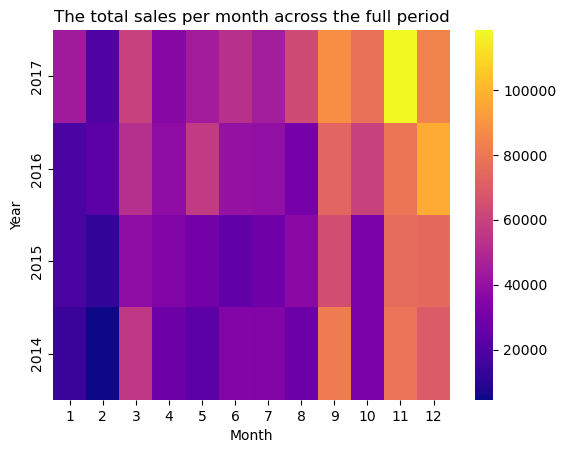

In [19]:
# Plotting the sales heatmap from the unstacked data
sns.heatmap(time_sales, cmap = 'plasma')
plt.gca().invert_yaxis()
plt.title("The total sales per month across the full period")
plt.show()

The fairest way to view the above graph is by comparing each value to the one above as we can see clear seasonal variation in sales, so by viewing the graph this way we can see that there is improvement over time as the amount in December 2014 is less than the amount in Decemeber 2017, and this pattern is clear throughout.

Next we can view this same data instead in terms of a linegraph over time.

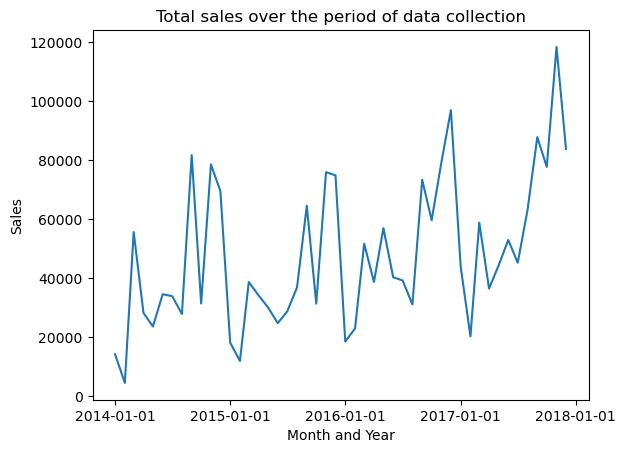

In [20]:
# Using the Month and Year sales data to plot the progression over time
sns.lineplot(monthly_sales)
plt.xticks(["2014-01", "2015-01", "2016-01", "2017-01", "2018-01"])
plt.title("Total sales over the period of data collection")
plt.show()

Similar to before, we see a positive growth on average and this seasonal variation is obvious as it follows the same pattern per year where it goes up overtime then drop at January of the next year.

### Profit over time

We will instead now look at the profit over the duration of the data collection period, the graph style is identical to sales for direct comparison.

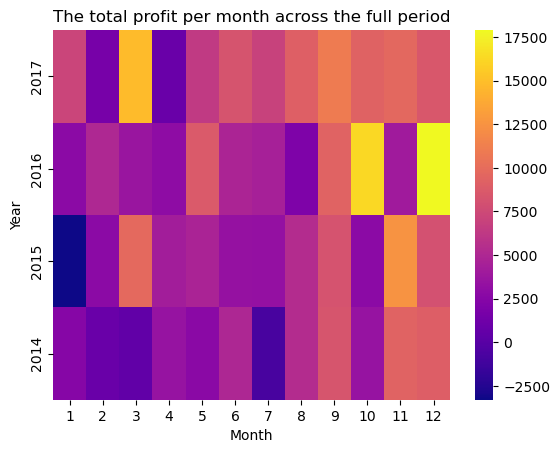

In [21]:
# Plotting the profit heatmap from the unstacked data
sns.heatmap(time_profit, cmap = 'plasma')
plt.gca().invert_yaxis()
plt.title("The total profit per month across the full period")
plt.show()

We see a different pattern this time, with improvement not being global or consistent, we instead see improvement in specific months over years more than others and random periods of good performance, for example July is steadily improving over time, but December profit decreases from 2014-2015 then in 2016 spikes to $\approx \$ 17500$ then back down to the rate found in 2015. 

We can infer there is still some progress over time but it is much more inconsistent compared to the sales data from before. As well as this, we see that profit in April and February are both something to focus on as its decreased for the last year or 2, and that July and September are doing something right depicted by their slow improvement.

Furthermore, we will look at the a linegraph the sum of profit per month of the performance over time to give a different performance over time instead.

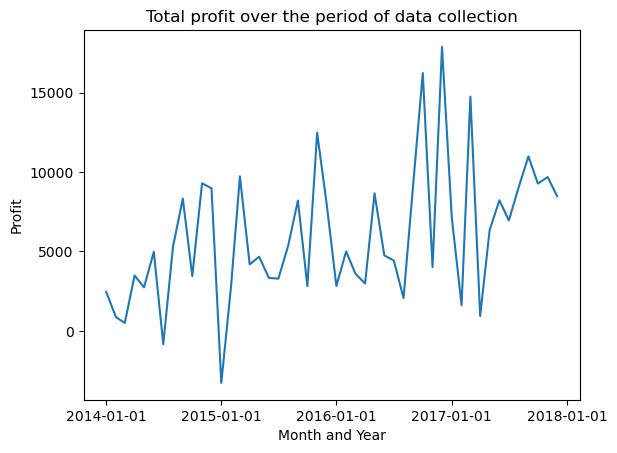

In [22]:
# Using the month and year to plot the profit over time
sns.lineplot(monthly_profit)
plt.xticks(["2014-01", "2015-01", "2016-01", "2017-01", "2018-01"])
plt.title("Total profit over the period of data collection")
plt.show()

In this above graph of profit over time we do see improvement in yielded profit over time at a similar rate to the sales but with a lot more variation and extreme points, which echo what we saw in the heatmap, with certain months having extremes, but overall profit increasing.

## Discount and Sales/Profit Performance

In this section we want to investigate the impact of discount on sales and profit performance, first we will look at the average sale amount per discount and then the average profit made on each discount given.

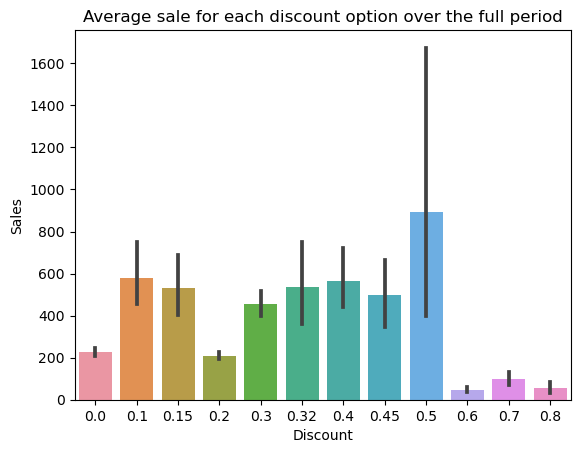

In [23]:
# Plotting the average sale price per discount bin
sns.barplot(data = df, x = 'Discount', y = 'Sales')
plt.title('Average sale for each discount option over the full period')
plt.show()

We see from this the most popular discount price other than none is 20% off, as the confidence interval is much smaller than the rest. Equally, we see that even though 50% off grants the highest average sale, the confidence interval is the highest by far, which means that this is represented by few actual sales so the information is not well evidenced. 

We also see 60%, 70% and 80% off do not grant high sales which is to be expected, as high ticket items are less likely to be this heavily discounted.

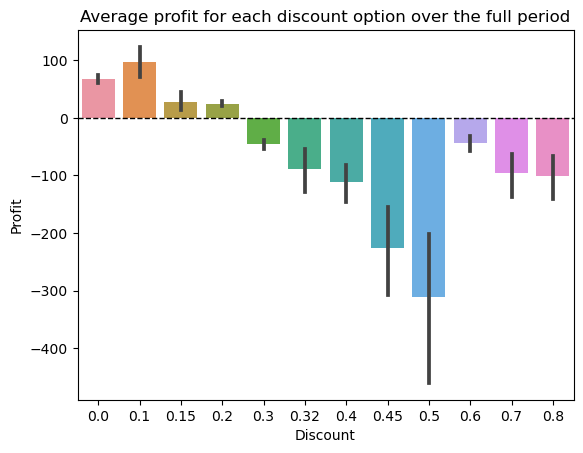

In [24]:
# Plotting instead the profit per discount bin
sns.barplot(data = df, x = 'Discount', y = 'Profit')
plt.title('Average profit for each discount option over the full period')
plt.axhline(0, color='black', linewidth=1, linestyle='--')
plt.show()

This graph now shows the actual impact of high discount items, as anything above 20% off is actually negative profit, and the most extreme case is 50% off, this means that high ticket items are being discounted at 50% off and it giving a severe loss on that item. This is likely the hole that is causing such poor returns on specific sub-categories.

But to confirm this we can go into detail on the bottom 3 and top 3 performing sub-categories and investigate what the average discount rate is for each.

In [25]:
# Filtering the bottom 3 sub-categories by profit
tables_df = df[df['Sub-Category'] == 'Tables']
bookcases_df = df[df['Sub-Category'] == 'Bookcases']
supplies_df = df[df['Sub-Category'] == 'Supplies']

# Finding the mean discount per sub-category
tables_discount = tables_df['Discount'].mean()
bookcases_discount = bookcases_df['Discount'].mean()
supplies_discount = supplies_df['Discount'].mean()

# Finding the mean profit per sub-category
tables_profit = tables_df['Profit'].mean()
bookcases_profit = bookcases_df['Profit'].mean()
supplies_profit = supplies_df['Profit'].mean()

print('Average Profit per sub-category')
print(f'Average Profit of a table sale:    {tables_profit:.2f}')
print(f'Average Profit of a bookcase sale: {bookcases_profit:.2f}')
print(f'Average Profit of a supplies sale: {supplies_profit:.2f}')

print('\nAverage Discount per sub-category')
print(f'Average Discount of a table sale:    {100 * tables_discount:.2f}%')
print(f'Average Discount of a bookcase sale: {100 * bookcases_discount:.2f}%')
print(f'Average Discount of a supplies sale: {100 * supplies_discount:.2f}%')


Average Profit per sub-category
Average Profit of a table sale:    -55.57
Average Profit of a bookcase sale: -15.23
Average Profit of a supplies sale: -6.26

Average Discount per sub-category
Average Discount of a table sale:    26.13%
Average Discount of a bookcase sale: 21.11%
Average Discount of a supplies sale: 7.68%


As previously suggested we do see that the negative profit is induced by higher discount rates, as the sub-category making the biggest loss is equally the sub-category with the highest discount rate across all orders under it. We also again see the drastic impact on profit that this has, as the loss made on Tables is nearly 3 times the loss made on the other 2 losing sub-categories.

In [26]:
# Filtering the top 3 sub-categories by profit
copiers_df = df[df['Sub-Category'] == 'Copiers']
phones_df = df[df['Sub-Category'] == 'Phones']
accessories_df = df[df['Sub-Category'] == 'Accessories']

# Selecting the mean discount for each sub-category
copiers_discount = copiers_df['Discount'].mean()
phones_discount = phones_df['Discount'].mean()
accessories_discount = accessories_df['Discount'].mean()

# Selecting the mean profit for each sub-category
copiers_profit = copiers_df['Profit'].mean()
phones_profit = phones_df['Profit'].mean()
accessories_profit = accessories_df['Profit'].mean()

print('Average Profit per sub-category')
print(f'Average Profit of a copier sale:    {copiers_profit:.2f}')
print(f'Average Profit of a phone sale:     {phones_profit:.2f}')
print(f'Average Profit of a accessory sale: {accessories_profit:.2f}')

print('\nAverage Discount per sub-category')
print(f'Average Discount of a copier sale:    {100 * copiers_discount:.2f}%')
print(f'Average Discount of a phone sale:     {100 * phones_discount:.2f}%')
print(f'Average Discount of a accessory sale: {100 * accessories_discount:.2f}%')

Average Profit per sub-category
Average Profit of a copier sale:    817.91
Average Profit of a phone sale:     50.07
Average Profit of a accessory sale: 54.11

Average Discount per sub-category
Average Discount of a copier sale:    16.18%
Average Discount of a phone sale:     15.46%
Average Discount of a accessory sale: 7.85%


Here, we see 2 different types of products, the first being high-ticket low-popularity items, the second being low-ticket high-popularity items, and the reason we see higher discount rates is because the item sale rate is much higher than cost to buy from suppliers, so the 16% on average discount on copiers does not dint the amount of profit made on them. 

This is how to do discounting correctly to maximise profit and popularity in comparison to the bottom 3 which instead are over discounted for the cost to supply.

## Conclusion

So overall, the results we have seen aim to highlight issues in the current working of the supermarkets accounted for in the dataset. And the main points to take home is that the furniture category needs significant work, as the money made by chairs and furnishing is almost entirely negated by the losses of table sales, which we can trace back to the over discounting of these items for high supply cost.

In terms of future actions, the main one is taking into account the size of the discrepancy between supply cost and sale price, when setting discount. As we can see with the copiers the discount works, but only in the case where the profit is still high enough beforehand. As copiers still yield on average $800 with an average 16\% discount, similarly the phone sales behave the exact same. Another action to possibly take though, is encouraging Home Office customers as they are the most profitable customer segment even though they are currently the least popular per sale they yield the most profit.

In general, the performance of the supermarkets across the USA is high, but sorting these issues we have discovered allows for future development into a very profitable business.



# Extension - Machine Learning

In this section we will look at using a linear regression model to predict the future state of the sales and profit figures of the dataset we have been dealing with. The programming allows for an inputted value for either sales or profit and by fitting the model to the data we have and then computing basic arithmetic to find the value of the sales or profit respectively for that many months in the future.

In [27]:
from sklearn import linear_model

# Setting up the model
sales_model = linear_model.LinearRegression()
profit_model = linear_model.LinearRegression()

# Calling the previously used data
profit_data = monthly_profit
sales_data = monthly_sales

# Setting up the data to train with for sales
X_sales = np.arange(len(monthly_sales)).reshape(-1, 1)
y_sales = np.array(monthly_sales)

# Setting up the data to train with for profit
X_profit = np.arange(len(monthly_profit)).reshape(-1, 1)
y_profit = np.array(monthly_profit)

# Fitting the model to the data
sales_model.fit(X_sales, y_sales)
profit_model.fit(X_profit, y_profit)

# Outputting basic information about the models fitment
print("--- Sales Model ---")
print("Slope (Growth per month):", sales_model.coef_[0])
print("Intercept:", sales_model.intercept_)
print("Sales R² Score:", sales_model.score(X_sales, y_sales))

print("\n--- Profit Model ---")
print("Slope (Growth per month):", profit_model.coef_[0])
print("Intercept:", profit_model.intercept_)
print("Profit R² Score:", profit_model.score(X_profit, y_profit))

--- Sales Model ---
Slope (Growth per month): 902.0075323111158
Intercept: 26661.174246938775
Sales R² Score: 0.2511984575232219

--- Profit Model ---
Slope (Growth per month): 139.21056589774204
Intercept: 2695.1563201530616
Profit R² Score: 0.2065139147262841


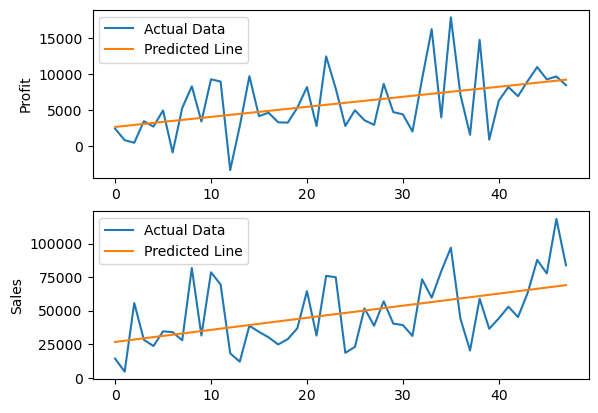

In [28]:
# Predicting a line of best fit the for data we are given
predicted_profit = profit_model.predict(X_profit)
predicted_sales = sales_model.predict(X_sales)

# Plotting the data in a 2 by 1 orientation
fig, ax = plt.subplots(2, 1)

# Printing both the actual sales data and the line of best fit
ax[0].plot(X_profit, y_profit, label = "Actual Data")
ax[0].plot(X_profit, predicted_profit, label = "Predicted Line")
ax[0].set_ylabel("Profit")
ax[0].legend()

# Printing both the actual profit data and the line of best fit
ax[1].plot(X_sales, y_sales, label = "Actual Data")
ax[1].plot(X_sales, predicted_sales, label = "Predicted Line")
ax[1].set_ylabel("Sales")
ax[1].legend()

plt.show()

In [34]:
# Allowing user input for the predicted sales
month = int(input("For how many month after the data would you like to predict sales for? "))
month += X_sales[-1]

output = sales_model.coef_[0] * month + sales_model.intercept_ 

print(f"The predicted sales from this current trend is: {output[0]:.2f}")

For how many month after the data would you like to predict sales for? 15
The predicted sales from this current trend is: 82585.64


In [36]:
month = int(input("For how many month after the data would you like to predict profit for? "))
month += X_sales[-1]

output = profit_model.coef_[0] * month + profit_model.intercept_ 

print(f"The predicted profit from this current trend is: {output[0]:.2f}")

For how many month after the data would you like to predict profit for? 60
The predicted profit from this current trend is: 17590.69
